In [ ]:
import pandas as pd
data = pd.read_csv('/content/retail_store_sales.csv')
df = data.copy()
df.head(50)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [ ]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


**Informal Missing Values Detection Cell**

In [ ]:
# Values that might be considered missing
suspects = ["unknown", "unk", "na", "n/a", "none", "null", "missing", "error", "?", "-", " ", ""]

for col in df.columns:
    print(f"\n=== {col} ===")
    vals = df[col].astype(str).str.lower().value_counts()

    found = vals[vals.index.isin(suspects)]
    if not found.empty:
        print(" Missing values written textually are present:")
        print(found)
    else:
        print("No missing values written as text — just actual nulls")



=== Transaction ID ===
No missing values written as text — just actual nulls

=== Customer ID ===
No missing values written as text — just actual nulls

=== Category ===
No missing values written as text — just actual nulls

=== Item ===
No missing values written as text — just actual nulls

=== Price Per Unit ===
No missing values written as text — just actual nulls

=== Quantity ===
No missing values written as text — just actual nulls

=== Total Spent ===
No missing values written as text — just actual nulls

=== Payment Method ===
No missing values written as text — just actual nulls

=== Location ===
No missing values written as text — just actual nulls

=== Transaction Date ===
No missing values written as text — just actual nulls

=== Discount Applied ===
No missing values written as text — just actual nulls


**Dynamic Generation of Static Price Lookup Map**

In [ ]:

category_map = {}

# We loop through each category in the file
# We take just one sample from it to know what its "abbreviation" is (for example, the abbreviation for Food is FOOD)
for category in df['Category'].unique():

   # Get any row where the Item name is not empty so we can take the abbreviation from it
    sample_item = df[df['Category'] == category]['Item'].dropna().iloc[0]

# By removing the name to get the last part (the Suffix)
# For example, Item_1_FOOD -> we just take the word FOOD
    suffix = sample_item.split('_')[-1]

   # build the 25 items of this category with the accounts
    items_dict = {}
    base_price = 5.0
    step = 1.5

    for i in range(1, 26):
        # Price equation: The price starts at 5 and increases by 1.5
        price = base_price + ((i - 1) * step)
        item_name = f"Item_{i}_{suffix}"

       # We add them to the dictionary
        items_dict[price] = item_name

    # We save the small dictionary inside the big dictionary under the name 'category'
    category_map[category] = items_dict

# Display the result to verify
print("The mapping for all categories has been successfully built")
print("\n Example of Food:")
print(category_map['Food'])

The mapping for all categories has been successfully built

 Example of Food:
{5.0: 'Item_1_FOOD', 6.5: 'Item_2_FOOD', 8.0: 'Item_3_FOOD', 9.5: 'Item_4_FOOD', 11.0: 'Item_5_FOOD', 12.5: 'Item_6_FOOD', 14.0: 'Item_7_FOOD', 15.5: 'Item_8_FOOD', 17.0: 'Item_9_FOOD', 18.5: 'Item_10_FOOD', 20.0: 'Item_11_FOOD', 21.5: 'Item_12_FOOD', 23.0: 'Item_13_FOOD', 24.5: 'Item_14_FOOD', 26.0: 'Item_15_FOOD', 27.5: 'Item_16_FOOD', 29.0: 'Item_17_FOOD', 30.5: 'Item_18_FOOD', 32.0: 'Item_19_FOOD', 33.5: 'Item_20_FOOD', 35.0: 'Item_21_FOOD', 36.5: 'Item_22_FOOD', 38.0: 'Item_23_FOOD', 39.5: 'Item_24_FOOD', 41.0: 'Item_25_FOOD'}


**Function for Inferring Missing Item Codes**

In [ ]:
def infer_item(row):
    cat = row["Category"]

# If the category is not in the map → return NaN
    if cat not in category_map:
        return row["Item"]

    # 1)If the Price Per Unit is available
    if pd.notna(row["Price Per Unit"]):
        price = round(float(row["Price Per Unit"]), 2)
        if price in category_map[cat]:
            return category_map[cat][price]

    # 2) If the Price Per Unit is missing → we calculate it from Total/Qty
    if pd.notna(row["Total Spent"]) and pd.notna(row["Quantity"]) and row["Quantity"] != 0:
        price = round(float(row["Total Spent"]) / float(row["Quantity"]), 2)
        if price in category_map[cat]:
            return category_map[cat][price]

    return row["Item"]

# We apply to the rows that have a missing Item
df["Item"] = df.apply(infer_item, axis=1)


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


**Efficient Imputation of Price Per Unit based on Static Item Code**

In [ ]:
item_to_price_map = {}
for price_item_dict in category_map.values():
    for price, item in price_item_dict.items():
        item_to_price_map[item] = price

def fill_price_from_item_efficient(row, check_map):

    if pd.notna(row['Price Per Unit']):
        return row['Price Per Unit']

    item_code = row['Item']

    if item_code in check_map:
        return check_map[item_code]

    return row['Price Per Unit']

df['Price Per Unit'] = df.apply(
    lambda row: fill_price_from_item_efficient(row, item_to_price_map),
    axis=1
)

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


**Identifying Rows Missing Both Quantity and Total Spent**

In [ ]:
mask_qty_missing = df['Quantity'].isna()

mask_total_missing = df['Total Spent'].isna()

missing_both_mask = mask_qty_missing & mask_total_missing

count_missing_both = missing_both_mask.sum()

print(f"The number of rows where Quantity and Total Spent are both missing is: {count_missing_both}")


The number of rows where Quantity and Total Spent are both missing is: 604


**Delete non-refundable sales records**

In [ ]:
initial_rows = len(df)

rows_to_drop_mask = mask_qty_missing & mask_total_missing

df = df.drop(df[rows_to_drop_mask].index)

df = df.reset_index(drop=True)

final_rows = len(df)
rows_dropped = initial_rows - final_rows

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


**The relationship between the discount column and the other columns**

Discount rate by Category:
Category
Furniture                             0.525941
Patisserie                            0.517277
Butchers                              0.514371
Beverages                             0.507231
Electric household essentials         0.502000
Computers and electric accessories    0.497070
Milk Products                         0.493732
Food                                  0.471698
Name: Discount Applied, dtype: float64

 Discount rate by Payment Method:
Payment Method
Cash              0.512754
Credit Card       0.505511
Digital Wallet    0.491878
Name: Discount Applied, dtype: float64

 Discount rate by Location:
Location
Online      0.506650
In-store    0.500127
Name: Discount Applied, dtype: float64

 Average Total Spent (0 = no discount, 1 = with discount):
Discount Applied
0.0    129.953330
1.0    130.491043
Name: Total Spent, dtype: float64


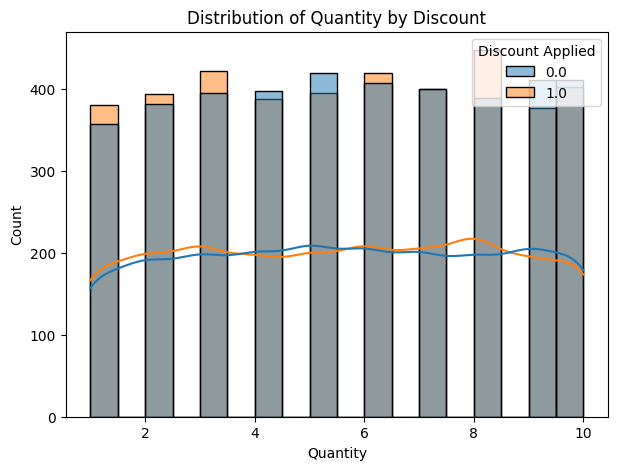

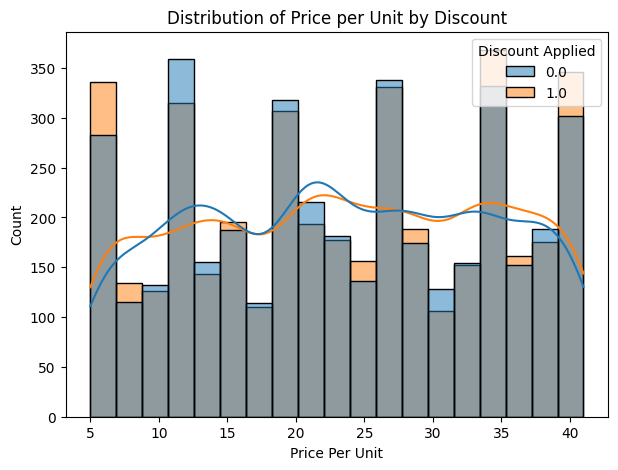


 Correlation matrix:
                  Discount Applied  Quantity  Price Per Unit  Total Spent
Discount Applied          1.000000 -0.008342        0.005655     0.002847
Quantity                 -0.008342  1.000000        0.005367     0.713473
Price Per Unit            0.005655  0.005367        1.000000     0.625580
Total Spent               0.002847  0.713473        0.625580     1.000000


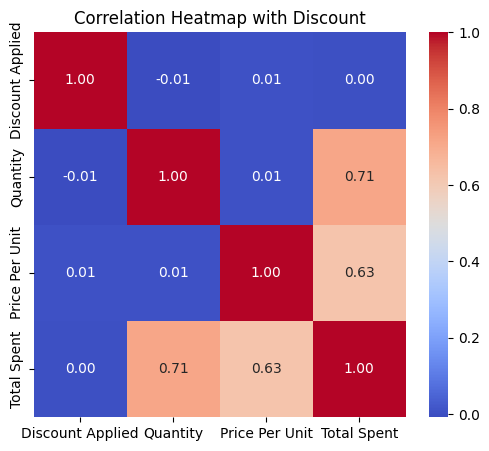

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Discount Applied'] = df['Discount Applied'].map({True:1, False:0})

category_trend = df.groupby("Category")['Discount Applied'].mean().sort_values(ascending=False)
print("Discount rate by Category:")
print(category_trend)


pay_trend = df.groupby("Payment Method")['Discount Applied'].mean().sort_values(ascending=False)
print("\n Discount rate by Payment Method:")
print(pay_trend)


loc_trend = df.groupby("Location")['Discount Applied'].mean().sort_values(ascending=False)
print("\n Discount rate by Location:")
print(loc_trend)


total_trend = df.groupby("Discount Applied")['Total Spent'].mean()
print("\n Average Total Spent (0 = no discount, 1 = with discount):")
print(total_trend)


plt.figure(figsize=(7,5))
sns.histplot(data=df, x="Quantity", hue="Discount Applied", kde=True)
plt.title("Distribution of Quantity by Discount")
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(data=df, x="Price Per Unit", hue="Discount Applied", kde=True)
plt.title("Distribution of Price per Unit by Discount")
plt.show()

numeric_df = df[['Discount Applied','Quantity','Price Per Unit','Total Spent']].dropna()

corr = numeric_df.corr()
print("\n Correlation matrix:")
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap with Discount")
plt.show()


**The Discount column has nothing to do with anything in the data. Not with Category, not with Payment Method, not with Location, nor with Total.**

**Probabilistic Imputation for Discount Column**

In [ ]:
prob_true = df['Discount Applied'].mean()

df['Discount Applied'] = df['Discount Applied'].apply(
    lambda x: np.random.choice([True, False], p=[prob_true, 1 - prob_true])
              if pd.isna(x) else x
)

print("Remaining NaN:", df['Discount Applied'].isna().sum())


Remaining NaN: 0


In [ ]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1.0
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0.0
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0.0


**Convert Discount Column to Binary Format**

In [ ]:
df['Discount Applied'] = df['Discount Applied'].apply(
    lambda x: 1 if x in [True, 1, 1.0, 'True'] else 0
)


In [ ]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,1
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0


In [ ]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


Convert Transaction Date to Datetime

In [ ]:
data['Transaction Date'] = pd.to_datetime(data['Transaction Date'])

In [ ]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11971 entries, 0 to 11970
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    11971 non-null  object 
 1   Customer ID       11971 non-null  object 
 2   Category          11971 non-null  object 
 3   Item              11971 non-null  object 
 4   Price Per Unit    11971 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    11971 non-null  object 
 8   Location          11971 non-null  object 
 9   Transaction Date  11971 non-null  object 
 10  Discount Applied  11971 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 1.0+ MB


,Price Per Unit,Quantity,Total Spent,Discount Applied
count,11971.000000,11971.000000,11971.000000,11971.000000
mean,23.360872,5.536380,129.652577,0.498120
std,10.741889,2.857883,94.750697,0.500017
min,5.000000,1.000000,5.000000,0.000000
25%,14.000000,3.000000,51.000000,0.000000
50%,23.000000,6.000000,108.500000,0.000000
75%,33.500000,8.000000,192.000000,1.000000
max,41.000000,10.000000,410.000000,1.000000


**Data Consistency Check**

In [ ]:
df['Expected_Total'] = df['Price Per Unit'] * df['Quantity']

inconsistent_rows = df[df['Total Spent'] != df['Expected_Total']]

print("Number of inconsistent rows:", inconsistent_rows.shape[0])
inconsistent_rows.head()


Number of inconsistent rows: 0


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Expected_Total


**Visual detection of outliers using boxplots**

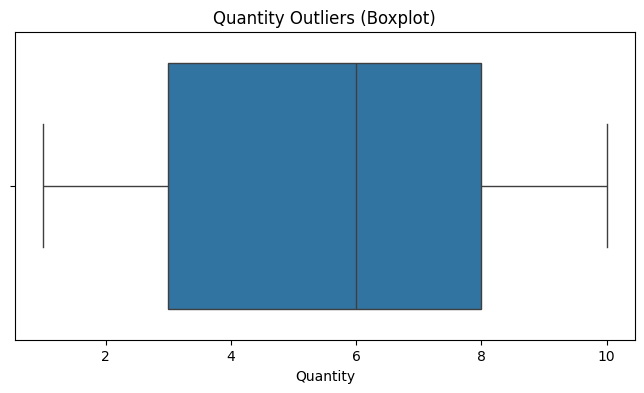

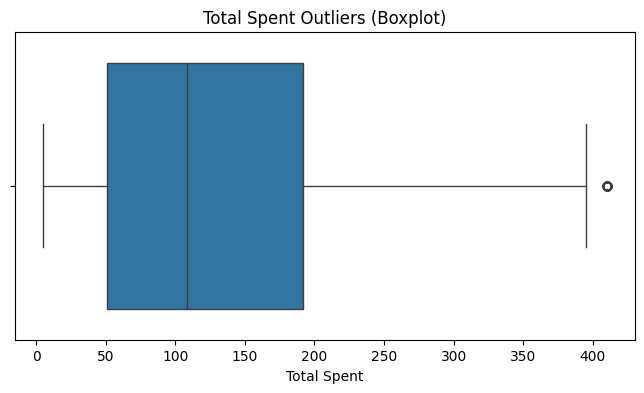

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Quantity'])
plt.title("Quantity Outliers (Boxplot)")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Total Spent'])
plt.title("Total Spent Outliers (Boxplot)")
plt.show()


**hendel out layeer in total spent**

In [ ]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print(f"Salary lower bound: {lower_bound}, upper bound: {upper_bound}")

Salary lower bound: 0, upper bound: 403.5


In [ ]:

high_spent_mask = df['Total Spent'] > 403.5

high_spent_transactions = df[high_spent_mask]

print(len(high_spent_transactions))


60


**Remove outlayers**

In [ ]:
df = df[(df['Total Spent'] >= lower_bound) & (df['Total Spent'] <= upper_bound)]

**Which categories sell the most?**

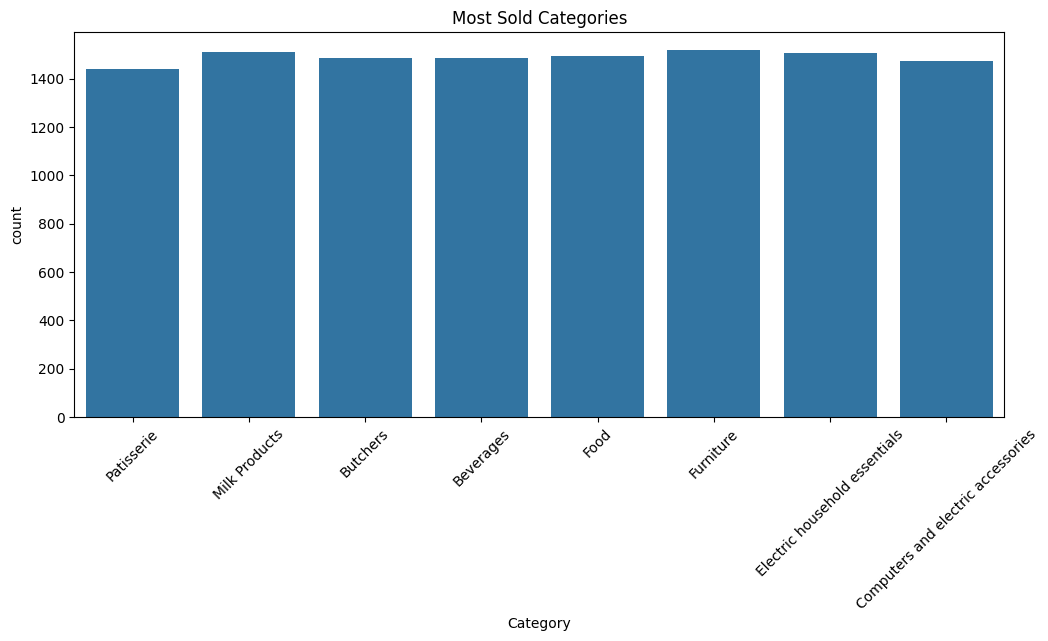

,count
Category,
Furniture,1517
Milk Products,1510
Electric household essentials,1506
Food,1495
Butchers,1485
Beverages,1485
Computers and electric accessories,1474
Patisserie,1439


In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Category')
plt.title("Most Sold Categories")
plt.xticks(rotation=45)
plt.show()

df['Category'].value_counts()


How are product prices distributed?

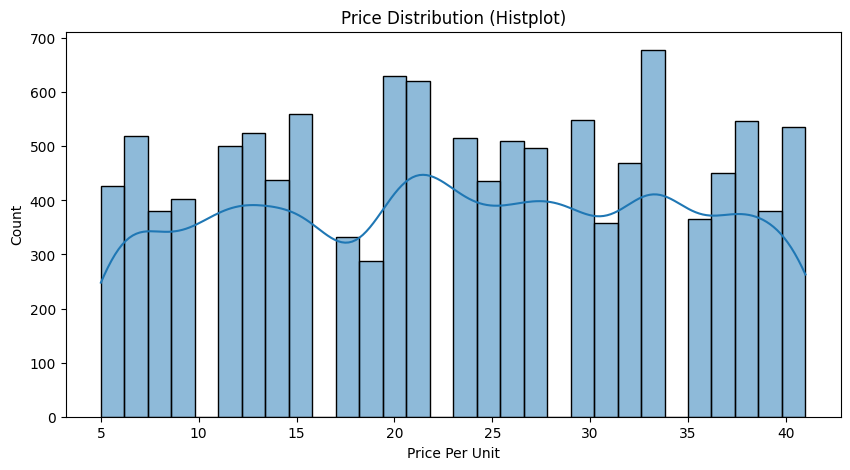

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price Per Unit'], bins=30, kde=True)
plt.title("Price Distribution (Histplot)")
plt.show()


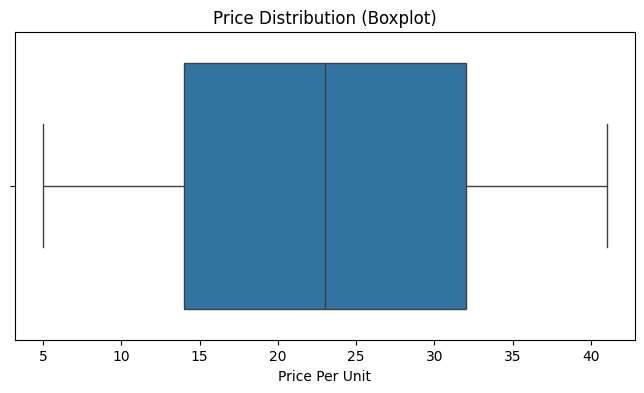

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Price Per Unit'])
plt.title("Price Distribution (Boxplot)")
plt.show()


**How are quantities distributed?**

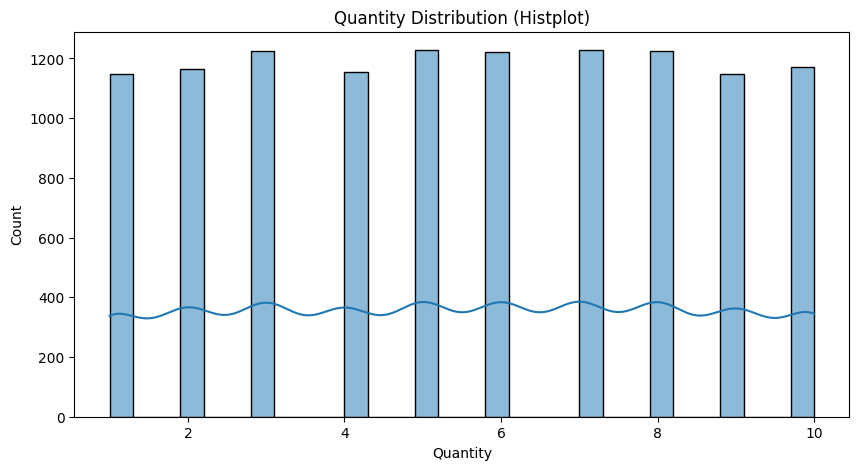

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title("Quantity Distribution (Histplot)")
plt.show()


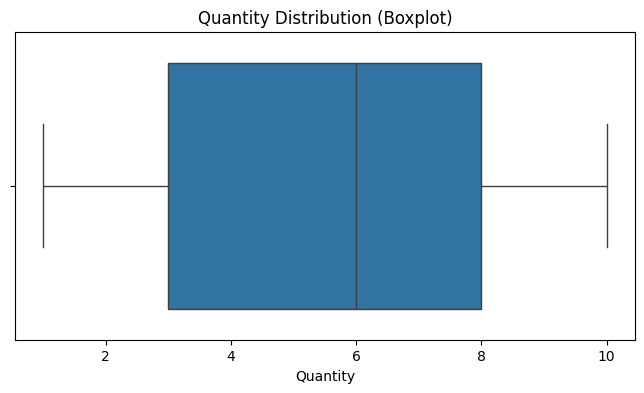

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Quantity'])
plt.title("Quantity Distribution (Boxplot)")
plt.show()


**What are the most common payment methods?**

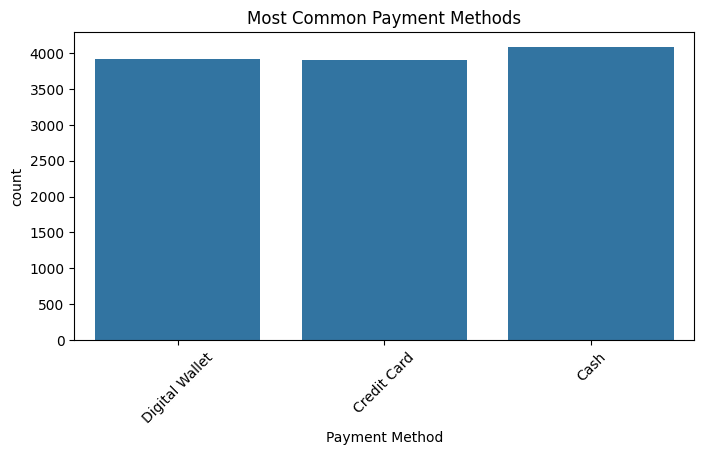

,count
Payment Method,
Cash,4088
Digital Wallet,3916
Credit Card,3907


In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Payment Method')
plt.title("Most Common Payment Methods")
plt.xticks(rotation=45)
plt.show()

df['Payment Method'].value_counts()


**Which customers purchase the most?**

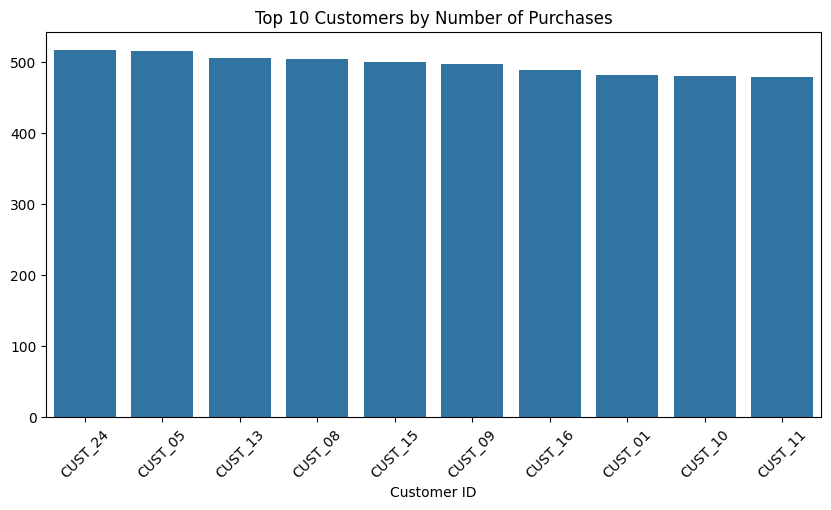

,count
Customer ID,
CUST_24,516
CUST_05,515
CUST_13,506
CUST_08,504
CUST_15,500
CUST_09,497
CUST_16,488
CUST_01,482
CUST_10,480


In [ ]:
top_customers = df['Customer ID'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.index, y=top_customers.values)
plt.title("Top 10 Customers by Number of Purchases")
plt.xticks(rotation=45)
plt.show()

top_customers


**Apply 15% discount if Discount Applied = True**

In [ ]:
df['Final_Total'] = df.apply(
    lambda row: row['Total Spent'] * 0.85 if row['Discount Applied'] == True else row['Total Spent'],
    axis=1
)

df[['Total Spent', 'Discount Applied', 'Final_Total']]


,Total Spent,Discount Applied,Final_Total
0,185.0,1,157.250
1,261.0,1,221.850
2,43.0,0,43.000
3,247.5,1,210.375
4,87.5,0,87.500
...,...,...,...
11966,152.0,1,129.200
11967,58.5,0,58.500
11968,140.0,1,119.000
11969,84.0,1,71.400


In [ ]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


In [ ]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [ ]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,datetime64[ns]


In [ ]:
df['Year'] = data['Transaction Date'].dt.year

In [ ]:
df['Day'] = df['Transaction Date'].dt.day_name()

In [ ]:
df['Month'] = df['Transaction Date'].dt.month_name()

In [ ]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Expected_Total,Final_Total,Month,Day,Year
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1,185.0,157.250,April,Monday,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1,261.0,221.850,July,Sunday,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0,43.0,43.000,October,Wednesday,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,1,247.5,210.375,May,Saturday,2022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0,87.5,87.500,October,Sunday,2022


**Which days have the highest number of sales?**

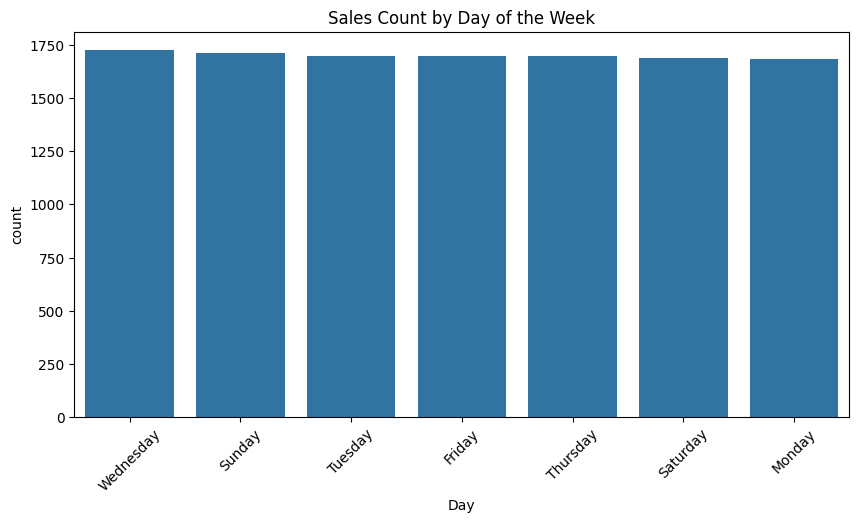

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Day', order=df['Day'].value_counts().index)
plt.title("Sales Count by Day of the Week")
plt.xticks(rotation=45)
plt.show()


**Which months have the highest number of sales?**

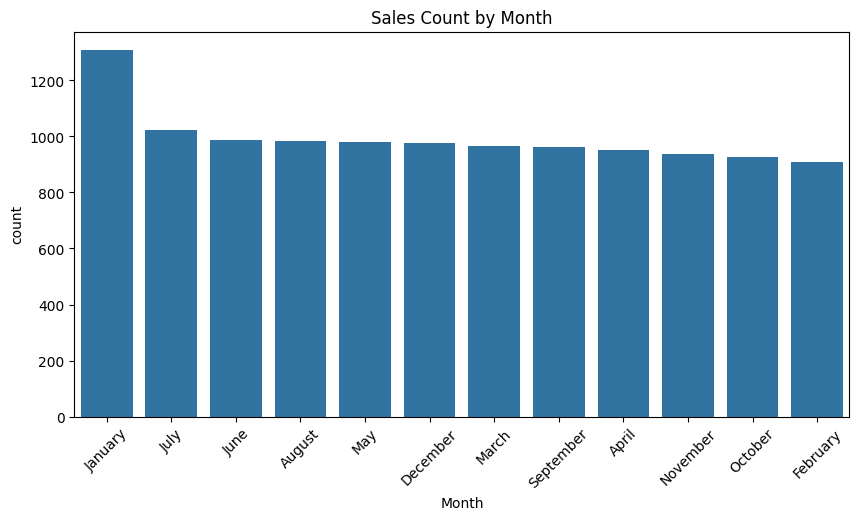

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Month', order=df['Month'].value_counts().index)
plt.title("Sales Count by Month")
plt.xticks(rotation=45)
plt.show()


**How many sales happened each year? **

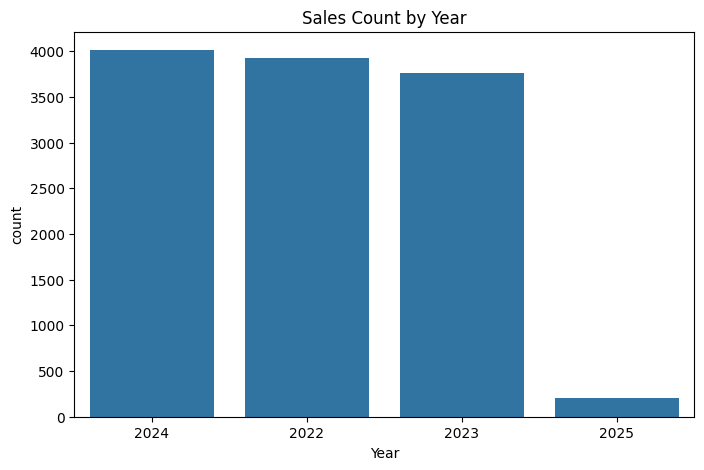

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Year', order=df['Year'].value_counts().index)
plt.title("Sales Count by Year")
plt.show()


**Which day generates the highest revenue?**

---



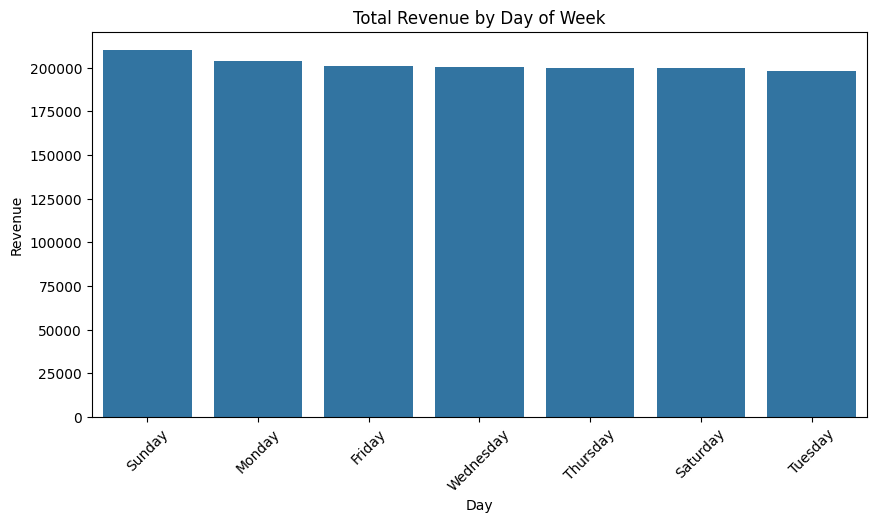

In [ ]:
day_revenue = df.groupby('Day')['Final_Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=day_revenue.index, y=day_revenue.values)
plt.title("Total Revenue by Day of Week")
plt.xticks(rotation=45)
plt.ylabel("Revenue")
plt.show()

